In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from shapely.validation import make_valid

ee.Initialize(project='omo-turkana-basin')

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


In [2]:
# Study area
shp_path = r"C:/Users/Admin/Desktop/KMD/Shapefiles/Kenya_shapes/Kenya/Kenya_region.shp"
aoi_gdf = gpd.read_file(shp_path)
print("Original:", aoi_gdf.crs)

aoi_gdf = aoi_gdf.to_crs(epsg=4326)
print("Reprojected:", aoi_gdf.crs)

aoi_gdf["geometry"] = aoi_gdf["geometry"].apply(make_valid).simplify(0.01)
aoi = geemap.geopandas_to_ee(aoi_gdf).geometry()

# Reusable AOI mask builder, for clipping any array to Kenya's true boundary in matplotlib
from shapely.ops import unary_union
from matplotlib.path import Path

def build_aoi_mask(shape):
    rows, cols = shape
    minx, miny, maxx, maxy = aoi_gdf.total_bounds
    lon = np.linspace(minx, maxx, cols)
    lat = np.linspace(maxy, miny, rows)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    points = np.vstack((lon_grid.ravel(), lat_grid.ravel())).T

    geom = unary_union(aoi_gdf.geometry)
    polys = [geom] if geom.geom_type == 'Polygon' else list(geom.geoms)
    mask = np.zeros(points.shape[0], dtype=bool)
    for poly in polys:
        path = Path(np.array(poly.exterior.coords))
        mask |= path.contains_points(points)
    return mask.reshape(rows, cols)

Original: EPSG:4210
Reprojected: EPSG:4326


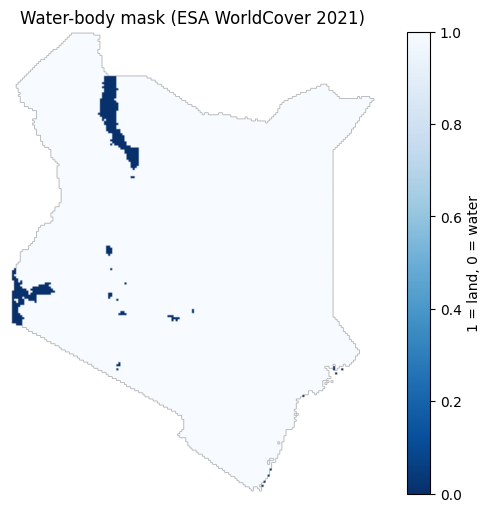

In [11]:
# Shared water-body mask (ESA WorldCover) - used to mask lakes/rivers consistently across every layer
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select('Map')
water_mask = worldcover.neq(80)  # 1 = land, 0 = permanent water body

# Quick visual check: confirm major lakes are correctly flagged                                  
water_check_arr = np.squeeze(ee_to_numpy(water_mask, region=aoi, scale=5000))
aoi_mask = build_aoi_mask(water_check_arr.shape)
water_check_masked = np.where(aoi_mask, water_check_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(water_check_masked, cmap='Blues_r')
plt.colorbar(label='1 = land, 0 = water')
plt.title('Water-body mask (ESA WorldCover 2021)')
plt.axis('off')
plt.show()

In [3]:
# HYDROGEOLOGY/ GEOLOGY

# Cell uploads Hydrogeology / geology layer (BGS Africa Groundwater Atlas - Kenya)
hg_path = r"C:\Users\Admin\Downloads\Kenya\Kenya\Kenya_HG.shp"
hg_gdf = gpd.read_file(hg_path)
print("Original:", hg_gdf.crs)

hg_gdf["geometry"] = hg_gdf["geometry"].apply(make_valid)

# Clip to AOI so it only covers the study area, consistent with your other layers
hg_gdf = gpd.clip(hg_gdf, aoi_gdf)

hydrogeology_fc = geemap.geopandas_to_ee(hg_gdf)

Original: EPSG:4326


In [4]:
#lets inspect the Hydrogeology/geology dataset
print("Feature count after clip:", len(hg_gdf))
print("Unique hydrogeology classes:", hg_gdf["KenHGComb"].unique())

Feature count after clip: 274
Unique hydrogeology classes: ['U/CSI-M/H' 'I-M' 'CSIF-M' 'B-L/M' 'n/a']


In [5]:
# Validate geometry, clip to AOI, mask out water bodies, and assign a recharge-favorability score
hg_gdf["geometry"] = hg_gdf["geometry"].apply(make_valid)
hg_gdf = gpd.clip(hg_gdf, aoi_gdf)
hg_gdf = hg_gdf[hg_gdf["KenHGComb"] != "n/a"].copy()

# Ordinal score (1 = lowest favorability, 4 = highest), based on aquifer type + productivity:
# B-L/M    = Basement, Low-Moderate productivity      -> lowest (fractured crystalline, poor storage)
# I-M      = Igneous/Volcanic, Moderate productivity   -> low-moderate
# CSIF-M   = Consolidated Sedimentary Intergranular/Fracture, Moderate -> moderate-high
# U/CSI-M/H = Unconsolidated/Semiconsolidated, Moderate-High           -> highest (best primary porosity)
hg_score_map = {
    "B-L/M": 1,
    "I-M": 2,
    "CSIF-M": 3,
    "U/CSI-M/H": 4,
}
hg_gdf["hg_score"] = hg_gdf["KenHGComb"].map(hg_score_map)

print(hg_gdf[["KenHGComb", "hg_score"]].drop_duplicates())

hydrogeology_fc = geemap.geopandas_to_ee(hg_gdf)

     KenHGComb  hg_score
254  U/CSI-M/H         4
252        I-M         2
246     CSIF-M         3
245      B-L/M         1


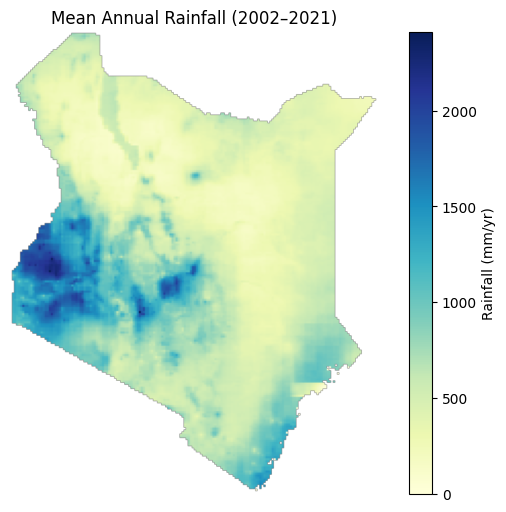

In [6]:
# RAINFALL
import matplotlib.pyplot as plt
from geemap import ee_to_numpy

chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
years = range(2002, 2022)  # 2002-2021 inclusive, matching LULC anchor year

def annual_total(year):
    col = chirps.filterDate(f"{year}-01-01", f"{year + 1}-01-01")
    return col.reduce(ee.Reducer.sum()).set('year', year)

annual_rain = ee.ImageCollection([annual_total(y) for y in years])

# Plot rainfall, masked to Kenya's true boundary
rain_arr = ee_to_numpy(annual_rain.mean(), region=aoi, scale=5000)
rain_arr = np.squeeze(rain_arr)  # drop single band dimension -> (rows, cols)
mask = build_aoi_mask(rain_arr.shape)
rain_arr_masked = np.where(mask, rain_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(rain_arr_masked, cmap='YlGnBu')
plt.colorbar(label='Rainfall (mm/yr)')
plt.title('Mean Annual Rainfall (2002–2021)')
plt.axis('off')
plt.show()

Annual PET collection size: 20


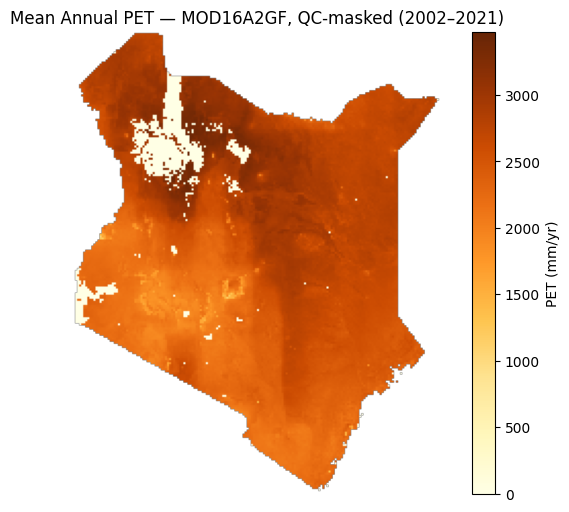

In [7]:
# PET - QC-masked
mod16 = ee.ImageCollection("MODIS/061/MOD16A2GF")  # gap-filled, covers 2000-present
years_pet = range(2002, 2022)  # 2002-2021 inclusive, matching rainfall/LULC

def annual_pet_total(year):
    col = mod16.filterDate(f"{year}-01-01", f"{year + 1}-01-01")
    def qc_masked(img):
        good_quality = img.select('ET_QC').bitwiseAnd(1).eq(0)  # bit 0 = 0 -> main algorithm, good quality
        return img.select('PET').multiply(0.1).updateMask(good_quality)
    pet_sum = col.map(qc_masked).sum().rename('PET')
    return pet_sum.set('year', year)

annual_pet = ee.ImageCollection([annual_pet_total(y) for y in years_pet])
print("Annual PET collection size:", annual_pet.size().getInfo())

# Plot mean annual PET, QC-masked and clipped to Kenya's true boundary
pet_arr = ee_to_numpy(annual_pet.mean(), region=aoi, scale=5000)
pet_arr = np.squeeze(pet_arr)
mask = build_aoi_mask(pet_arr.shape)
pet_arr_masked = np.where(mask, pet_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(pet_arr_masked, cmap='YlOrBr')
plt.colorbar(label='PET (mm/yr)')
plt.title('Mean Annual PET — MOD16A2GF, QC-masked (2002–2021)')
plt.axis('off')
plt.show()

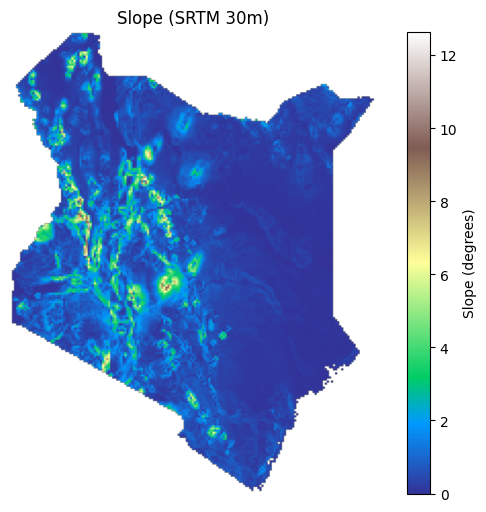

In [8]:
# TOPOGRAPHY
dem = ee.Image("USGS/SRTMGL1_003")
slope = ee.Terrain.slope(dem)

# Pull to local array and plot, masked to Kenya's true boundary
slope_arr = ee_to_numpy(slope, region=aoi, scale=5000)
slope_arr = np.squeeze(slope_arr)
mask = build_aoi_mask(slope_arr.shape)
slope_arr_masked = np.where(mask, slope_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(slope_arr_masked, cmap='terrain')
plt.colorbar(label='Slope (degrees)')
plt.title('Slope (SRTM 30m)')
plt.axis('off')
plt.show()

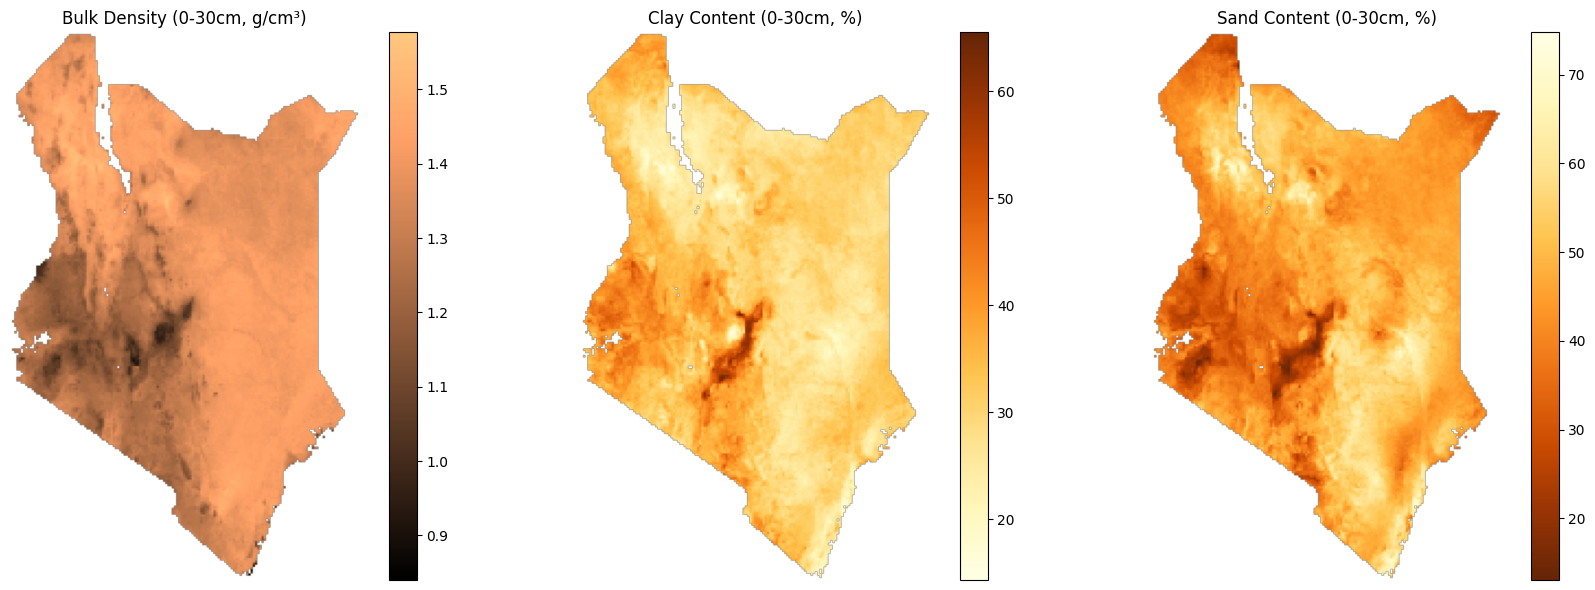

In [9]:
# Saturated Hydraulic Conductivity (permeability) - soil property inputs
# Checks how fast water can move through the soil when it's fully saturated
# Has multiple depth bands; averaged over 0-30cm for analysis
# Units: cm/day or cm/hr
# Ksat itself computed over the next 3 cells using the Saxton-Rawls equation

# Soil properties
bdod = ee.Image("projects/soilgrids-isric/bdod_mean")
clay = ee.Image("projects/soilgrids-isric/clay_mean")
sand = ee.Image("projects/soilgrids-isric/sand_mean")

def avg_0_30cm(img, prefix):
    bands = [f"{prefix}_0-5cm_mean", f"{prefix}_5-15cm_mean", f"{prefix}_15-30cm_mean"]
    return img.select(bands).reduce(ee.Reducer.mean())

bulk_density = avg_0_30cm(bdod, 'bdod').divide(100)   # cg/cm3 -> g/cm3 (ISRIC conversion factor, confirmed)
clay_pct     = avg_0_30cm(clay, 'clay').divide(10)    # g/kg -> % (ISRIC conversion factor, confirmed)
sand_pct     = avg_0_30cm(sand, 'sand').divide(10)    # g/kg -> % (ISRIC conversion factor, confirmed)

# Pull values AND each layer's own validity mask (SoilGrids marks water/nodata pixels internally)
bd_arr    = np.squeeze(ee_to_numpy(bulk_density, region=aoi, scale=5000))
clay_arr  = np.squeeze(ee_to_numpy(clay_pct, region=aoi, scale=5000))
sand_arr  = np.squeeze(ee_to_numpy(sand_pct, region=aoi, scale=5000))

bd_valid   = np.squeeze(ee_to_numpy(bulk_density.mask(), region=aoi, scale=5000))
clay_valid = np.squeeze(ee_to_numpy(clay_pct.mask(), region=aoi, scale=5000))
sand_valid = np.squeeze(ee_to_numpy(sand_pct.mask(), region=aoi, scale=5000))

# Combine AOI boundary mask with each layer's own validity mask
aoi_mask = build_aoi_mask(bd_arr.shape)
bd_arr_masked   = np.where(aoi_mask & (bd_valid > 0), bd_arr, np.nan)
clay_arr_masked = np.where(aoi_mask & (clay_valid > 0), clay_arr, np.nan)
sand_arr_masked = np.where(aoi_mask & (sand_valid > 0), sand_arr, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(bd_arr_masked, cmap='copper')
axes[0].set_title('Bulk Density (0-30cm, g/cm³)')
axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(clay_arr_masked, cmap='YlOrBr')
axes[1].set_title('Clay Content (0-30cm, %)')
axes[1].axis('off')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(sand_arr_masked, cmap='YlOrBr_r')
axes[2].set_title('Sand Content (0-30cm, %)')
axes[2].axis('off')
fig.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

Annual ET collection size: 20


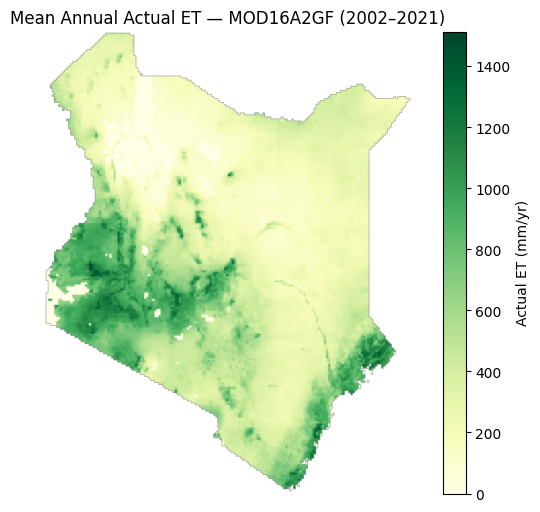

In [12]:
# ACTUAL EVAPOTRANSPIRATION
def annual_et_total(year):
    col = mod16.filterDate(f"{year}-01-01", f"{year + 1}-01-01")
    def qc_masked(img):
        good_quality = img.select('ET_QC').bitwiseAnd(1).eq(0)
        return img.select('ET').multiply(0.1).updateMask(good_quality)
    et_sum = col.map(qc_masked).sum().updateMask(water_mask).rename('ET')
    return et_sum.set('year', year)

annual_et = ee.ImageCollection([annual_et_total(y) for y in years_pet])
print("Annual ET collection size:", annual_et.size().getInfo())

et_arr = ee_to_numpy(annual_et.mean(), region=aoi, scale=5000)
et_arr = np.squeeze(et_arr)
aoi_mask = build_aoi_mask(et_arr.shape)
et_arr_masked = np.where(aoi_mask, et_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(et_arr_masked, cmap='YlGn')
plt.colorbar(label='Actual ET (mm/yr)')
plt.title('Mean Annual Actual ET — MOD16A2GF (2002–2021)')
plt.axis('off')
plt.show()

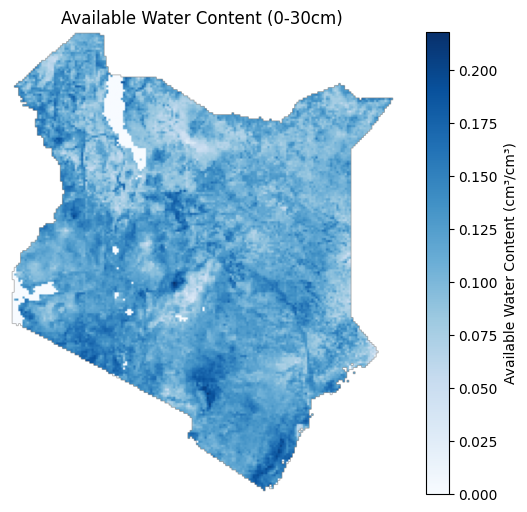

In [13]:
# Soil Water Storage: Available Water Content (0-30cm, Field Capacity - Wilting Point)
wv0033 = ee.Image('ISRIC/SoilGrids250m/v2_0/wv0033')
wv1500 = ee.Image('ISRIC/SoilGrids250m/v2_0/wv1500')

def avg_0_30cm_water(img):
    bands = ['val_0_5cm_mean', 'val_5_15cm_mean', 'val_15_30cm_mean']
    return img.select(bands).reduce(ee.Reducer.mean())

fc_030  = avg_0_30cm_water(wv0033)   # already in cm3/cm3 as served by this GEE asset - confirmed empirically
wp_030  = avg_0_30cm_water(wv1500)
awc_030 = fc_030.subtract(wp_030).rename('AWC').updateMask(water_mask)  # available water content, cm3/cm3

# Pull to local array, mask to Kenya's true boundary, and plot
awc_arr = ee_to_numpy(awc_030, region=aoi, scale=5000)
awc_arr = np.squeeze(awc_arr)
aoi_mask = build_aoi_mask(awc_arr.shape)
awc_arr_masked = np.where(aoi_mask, awc_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(awc_arr_masked, cmap='Blues')
plt.colorbar(label='Available Water Content (cm³/cm³)')
plt.title('Available Water Content (0-30cm)')
plt.axis('off')
plt.show()

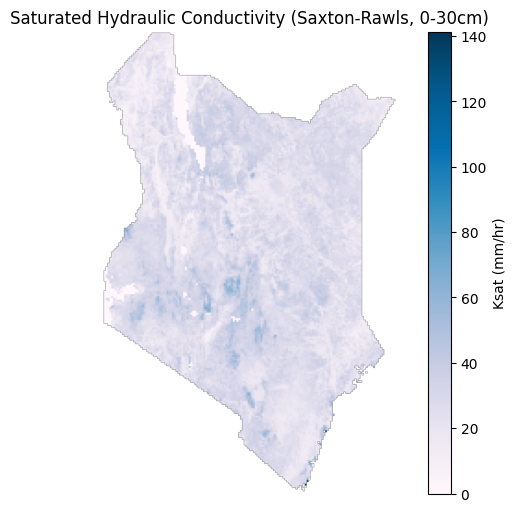

In [14]:
# Ksat via Saxton & Rawls (2006) conductivity
# KS = 1930 × (θS − θ33)^(3−λ)
# θS = saturated moisture content (i.e., porosity), estimated here as 1 - bulk_density/2.65 (standard mineral particle density assumption)
# θ33 = moisture at field capacity (33 kPa)
# λ = 1/B, where B = [ln(1500) − ln(33)] / [ln(θ33) − ln(θ1500)]
# θ1500 = moisture at wilting point (1500 kPa)
# KS comes out in mm/hour

import math

theta_s = ee.Image(1).subtract(bulk_density.divide(2.65)).updateMask(water_mask)
fc_masked = fc_030.updateMask(water_mask)
wp_masked = wp_030.updateMask(water_mask)

B = (ee.Image(math.log(1500)).subtract(math.log(33))) \
    .divide(fc_masked.log().subtract(wp_masked.log()))
lam = ee.Image(1).divide(B)

# Saturated hydraulic conductivity (mm/hr)
ksat = ee.Image(1930).multiply(
    theta_s.subtract(fc_masked).pow(ee.Image(3).subtract(lam))
).rename('Ksat')

# Plot, masked to Kenya's true boundary
ksat_arr = ee_to_numpy(ksat, region=aoi, scale=5000)
ksat_arr = np.squeeze(ksat_arr)
aoi_mask = build_aoi_mask(ksat_arr.shape)
ksat_arr_masked = np.where(aoi_mask, ksat_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(ksat_arr_masked, cmap='PuBu')
plt.colorbar(label='Ksat (mm/hr)')
plt.title('Saturated Hydraulic Conductivity (Saxton-Rawls, 0-30cm)')
plt.axis('off')
plt.show()

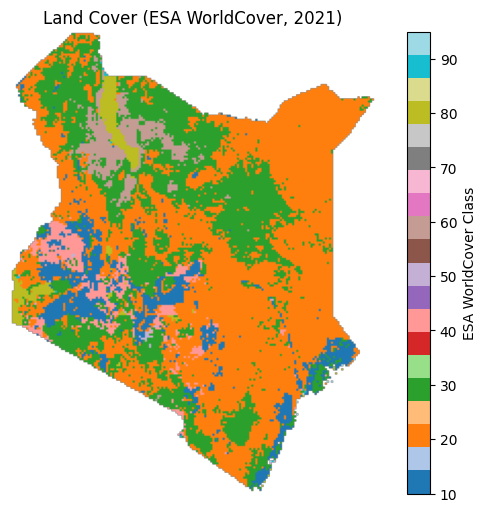

In [15]:
# LULC (ESA WorldCover 2021) - land cover as a surface modifier on infiltration
# 11 classes: 10=Tree cover, 20=Shrubland, 30=Grassland, 40=Cropland, 50=Built-up,
# 60=Bare/sparse vegetation, 70=Snow/ice, 80=Permanent water bodies, 90=Herbaceous wetland,
# 95=Mangroves, 100=Moss/lichen

lulc = worldcover.rename('lulc')  # reuses the WorldCover image already loaded in cell 3

# Pull to local array, mask to Kenya's true boundary, and plot
lulc_arr = ee_to_numpy(lulc, region=aoi, scale=5000)
lulc_arr = np.squeeze(lulc_arr)
aoi_mask = build_aoi_mask(lulc_arr.shape)
lulc_arr_masked = np.where(aoi_mask, lulc_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(lulc_arr_masked, cmap='tab20')
plt.colorbar(label='ESA WorldCover Class')
plt.title('Land Cover (ESA WorldCover, 2021)')
plt.axis('off')
plt.show()

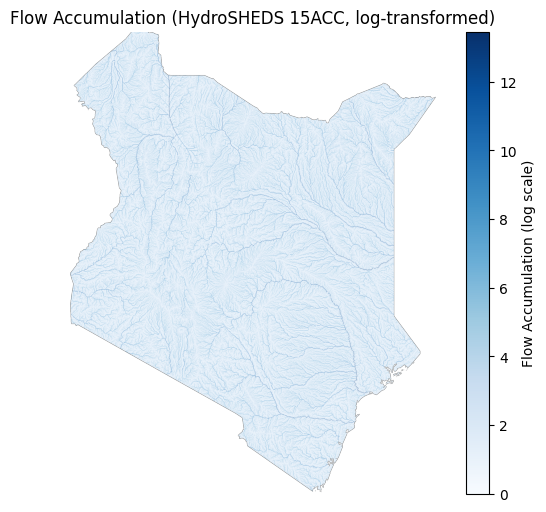

Flow accumulation at Tana River point: {'b1': 495}


In [18]:
#DRAINAGE DENSITY
#1. Pull and visualize flow accumulation
flow_acc = ee.Image("WWF/HydroSHEDS/15ACC").select('b1')

# Pull to local array, mask to Kenya's true boundary
flow_acc_arr = ee_to_numpy(flow_acc, region=aoi, scale=500)
flow_acc_arr = np.squeeze(flow_acc_arr)
aoi_mask = build_aoi_mask(flow_acc_arr.shape)
flow_acc_masked = np.where(aoi_mask, flow_acc_arr, np.nan)

# Flow accumulation is extremely right-skewed (most pixels near 0, rivers spike to millions),
# so log scale is needed to see the drainage network at all
flow_acc_log = np.log1p(flow_acc_masked)

plt.figure(figsize=(8, 6))
plt.imshow(flow_acc_log, cmap='Blues')
plt.colorbar(label='Flow Accumulation (log scale)')
plt.title('Flow Accumulation (HydroSHEDS 15ACC, log-transformed)')
plt.axis('off')
plt.show()

# Sanity check against the Tana River point again, now with the correct asset
tana_val = flow_acc.reduceRegion(
    reducer=ee.Reducer.max(), geometry=ee.Geometry.Point([39.9833, -1.6333]).buffer(1000),
    scale=500, maxPixels=1e9
).getInfo()
print("Flow accumulation at Tana River point:", tana_val)

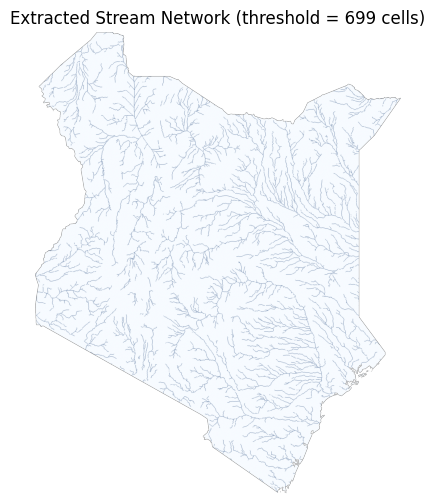

In [20]:
# 2. Threshold and extract stream network
# Using a percentage-of-maximum threshold (resolution-agnostic), since published cell-count
# thresholds are calibrated for 90m DEMs, not this dataset's ~464m native resolution.
stream_threshold = 698853 * 0.001  # 0.1% of max accumulation - starting point, adjustable

streams = flow_acc.gte(stream_threshold).selfMask().rename('streams')

# Pull to local array, mask to Kenya's true boundary, and plot
streams_arr = ee_to_numpy(streams, region=aoi, scale=500)
streams_arr = np.squeeze(streams_arr)
aoi_mask = build_aoi_mask(streams_arr.shape)
streams_masked = np.where(aoi_mask, streams_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(streams_masked, cmap='Blues')
plt.title(f'Extracted Stream Network (threshold = {stream_threshold:.0f} cells)')
plt.axis('off')
plt.show()

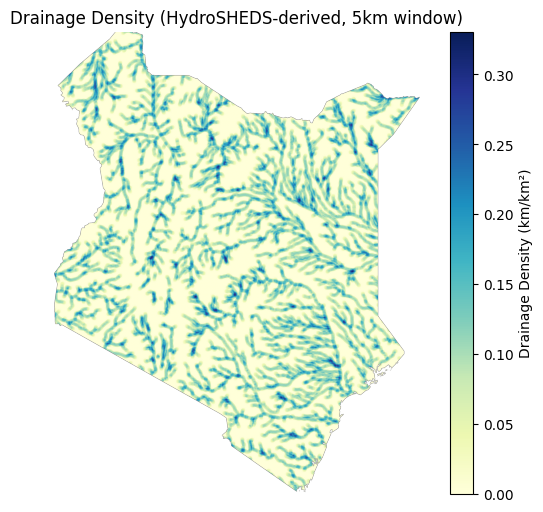

In [32]:
#3.5km radius to match the ~5km working scale
# used by the rest of the model's layers (rainfall, PET, Ksat, AWC, slope)

pixel_size_km = 463.83 / 1000  # native HydroSHEDS resolution, ~464m
window_radius_m = 5000          # matches the model's common working scale

kernel = ee.Kernel.circle(radius=window_radius_m, units='meters', normalize=False)
stream_pixel_count = streams.unmask(0).convolve(kernel)

window_area_km2 = math.pi * (window_radius_m / 1000) ** 2
drainage_density = stream_pixel_count.multiply(pixel_size_km).divide(window_area_km2).rename('drainage_density')

# Pull to local array, mask to Kenya's true boundary, and plot
dd_arr = ee_to_numpy(drainage_density, region=aoi, scale=500)
dd_arr = np.squeeze(dd_arr)
aoi_mask = build_aoi_mask(dd_arr.shape)
dd_arr_masked = np.where(aoi_mask, dd_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(dd_arr_masked, cmap='YlGnBu')
plt.colorbar(label='Drainage Density (km/km²)')
plt.title('Drainage Density (HydroSHEDS-derived, 5km window)')
plt.axis('off')
plt.show()

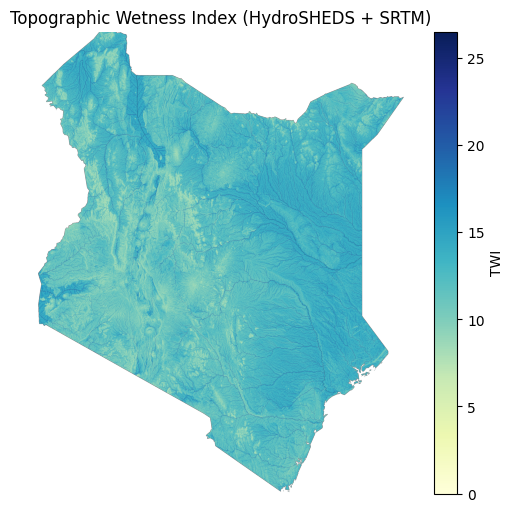

TWI percentiles across Kenya: {'TWI_p5': 9.313701857124213, 'TWI_p50': 12.080659417777547, 'TWI_p95': 16.6881994630578}


In [34]:
#TWI Topographic Wetness Index
# TWI = ln(a / tan(slope)), where a = specific catchment area (flow accumulation converted to area)
# Higher TWI = flat, water-accumulating terrain (valleys) = higher recharge potential
# Lower TWI = steep, well-drained terrain (hillslopes) = lower recharge potential

pixel_size_m = 463.83  # HydroSHEDS native resolution

slope_rad = slope.multiply(math.pi / 180)  # slope was already computed in degrees in the slope cell
tan_slope = slope_rad.tan().max(0.001)     # epsilon avoids division by zero on flat terrain

specific_catchment_area = flow_acc.add(1).multiply(pixel_size_m)  # +1 avoids log(0) on headwater cells

twi = specific_catchment_area.divide(tan_slope).log().rename('TWI').updateMask(water_mask)

# Combine into one pull (both bands resolved on the same grid, avoiding the shape-mismatch issue from before)
twi_arr = ee_to_numpy(twi, region=aoi, scale=500)
twi_arr = np.squeeze(twi_arr)
aoi_mask = build_aoi_mask(twi_arr.shape)
twi_arr_masked = np.where(aoi_mask, twi_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(twi_arr_masked, cmap='YlGnBu')
plt.colorbar(label='TWI')
plt.title('Topographic Wetness Index (HydroSHEDS + SRTM)')
plt.axis('off')
plt.show()

# Plausibility check - TWI commonly ranges ~2-20+ in real terrain (low on steep slopes, high in valleys/floodplains)
stats = twi.reduceRegion(
    reducer=ee.Reducer.percentile([5, 50, 95]), geometry=aoi, scale=500, maxPixels=1e9, bestEffort=True
).getInfo()
print("TWI percentiles across Kenya:", stats)

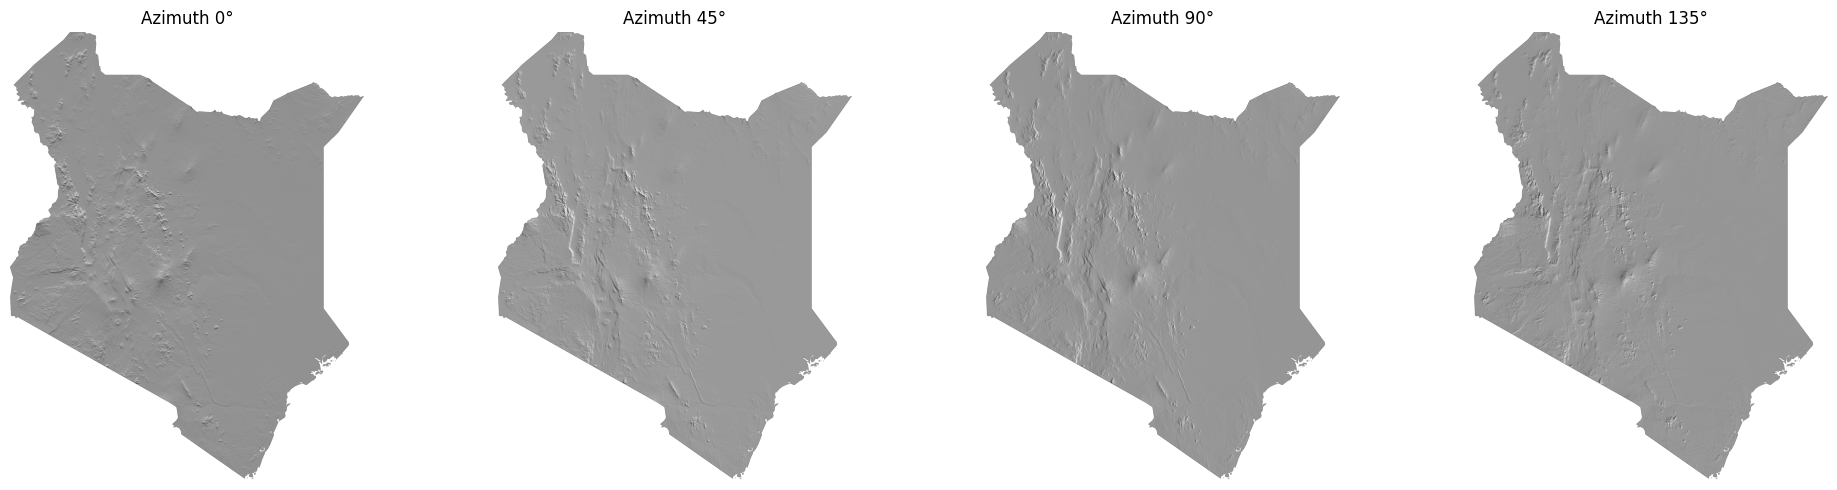

In [35]:
# LINEAMENT DENSITY
#1.Multi-azimuth hillshade (mitigates directional bias in edge detection)
azimuths = [0, 45, 90, 135]  # four lighting directions; combining reduces bias toward lineaments
                               # that happen to align with any single light direction

hillshades = [ee.Terrain.hillshade(dem, az, 45) for az in azimuths]  # elevation angle 45, standard default

# Visualize all four to confirm they look like sensible relief images before combining
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, (az, hs) in enumerate(zip(azimuths, hillshades)):
    hs_arr = np.squeeze(ee_to_numpy(hs, region=aoi, scale=500))
    aoi_mask_hs = build_aoi_mask(hs_arr.shape)
    hs_masked = np.where(aoi_mask_hs, hs_arr, np.nan)
    axes[i].imshow(hs_masked, cmap='gray')
    axes[i].set_title(f'Azimuth {az}°')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

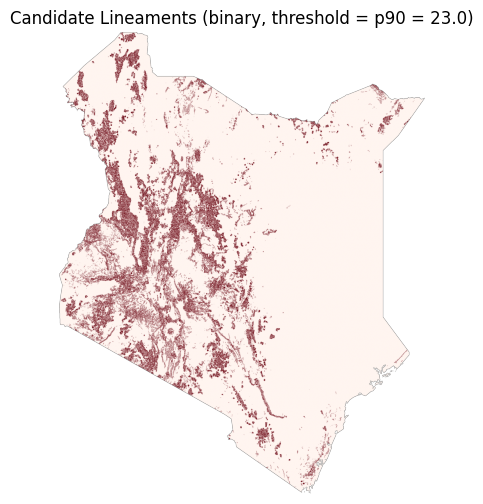

In [42]:
#2. Canny edge detection + binarization into candidate lineaments
azimuths = [0, 45, 90, 135]
hillshades = [ee.Terrain.hillshade(dem, az, 45) for az in azimuths]

edges_list = []
for hs in hillshades:
    hs_float = hs.toFloat()
    edges = ee.Algorithms.CannyEdgeDetector(hs_float, threshold=4, sigma=1)
    edges_list.append(edges)

combined_edges = ee.ImageCollection(edges_list).max().rename('lineaments')

# CannyEdgeDetector returns a continuous edge-strength image (confirmed via
# min/max diagnostic: 0-386), not a binary mask, so we threshold it explicitly.
# Cutoff = empirically observed 90th percentile of edge strength (data-driven,
# same reasoning used for the drainage-density stream threshold).
lineament_threshold = 22.98

lineaments_binary = combined_edges.gt(lineament_threshold).selfMask().rename('lineaments')

# Visualize
lin_arr = np.squeeze(ee_to_numpy(lineaments_binary, region=aoi, scale=500))
aoi_mask = build_aoi_mask(lin_arr.shape)
lin_masked = np.where(aoi_mask, lin_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(lin_masked, cmap='Reds')
plt.title(f'Candidate Lineaments (binary, threshold = p90 = {lineament_threshold:.1f})')
plt.axis('off')
plt.show()

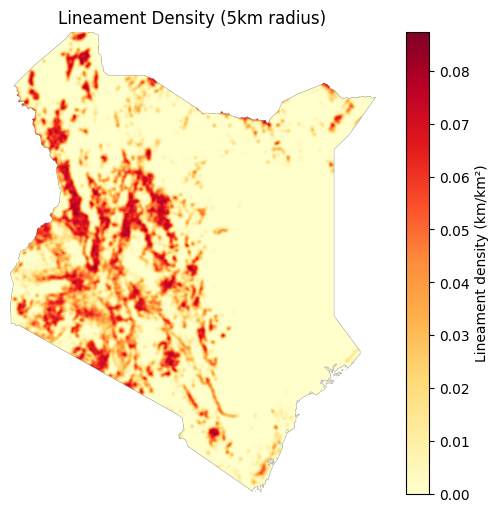

Lineament density percentiles:
[0.         0.         0.04545465 0.05958761]


In [43]:
# Lineament Density - Step 3: moving-window convolution (same approach as drainage density)
window_radius_m = 5000

kernel = ee.Kernel.circle(radius=window_radius_m, units='meters', normalize=False)
lineament_pixel_count = lineaments_binary.unmask(0).convolve(kernel)

# Lineament pixels are at 30m native resolution (SRTM/hillshade-derived),
# distinct from the 463.83m HydroSHEDS grid used for drainage density
lineament_pixel_size_km = 30 / 1000
window_area_km2 = math.pi * (window_radius_m / 1000) ** 2

lineament_density = lineament_pixel_count.multiply(lineament_pixel_size_km).divide(window_area_km2).rename('lineament_density')

# Pull and visualize
lin_density_arr = np.squeeze(ee_to_numpy(lineament_density, region=aoi, scale=500))
aoi_mask = build_aoi_mask(lin_density_arr.shape)
lin_density_masked = np.where(aoi_mask, lin_density_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(lin_density_masked, cmap='YlOrRd')
plt.colorbar(label='Lineament density (km/km²)')
plt.title('Lineament Density (5km radius)')
plt.axis('off')
plt.show()

print("Lineament density percentiles:")
print(np.nanpercentile(lin_density_masked, [5, 50, 90, 95]))

In [45]:
import numpy as np

params = ['Rainfall', 'PET', 'Hydrogeology', 'Ksat', 'AWC', 'Slope',
          'LULC', 'Drainage_Density', 'TWI', 'Lineament_Density']

tier = {
    'Rainfall': 1, 'Hydrogeology': 1, 'Slope': 1,
    'PET': 2, 'Lineament_Density': 2,
    'Ksat': 3, 'AWC': 3, 'LULC': 3, 'Drainage_Density': 3,
    'TWI': 4
}

# Saaty-scale judgment for each tier pair (how much more important tier i is than tier j)
tier_judgment = {
    (1, 1): 1, (2, 2): 1, (3, 3): 1, (4, 4): 1,
    (1, 2): 3, (1, 3): 4, (1, 4): 6,
    (2, 3): 2, (2, 4): 4,
    (3, 4): 3,
}

n = len(params)
pairwise = np.ones((n, n))
for i, pi in enumerate(params):
    for j, pj in enumerate(params):
        if i == j:
            continue
        ti, tj = tier[pi], tier[pj]
        if ti <= tj:
            pairwise[i, j] = tier_judgment[(ti, tj)] if ti != tj else 1
        else:
            pairwise[i, j] = 1 / tier_judgment[(tj, ti)]

eigvals, eigvecs = np.linalg.eig(pairwise)
max_idx = np.argmax(eigvals.real)
weights = eigvecs[:, max_idx].real
weights = weights / weights.sum()

lambda_max = eigvals[max_idx].real
CI = (lambda_max - n) / (n - 1)
RI = 1.49  # n=10
CR = CI / RI

print("AHP-derived weights:")
for p, w in sorted(zip(params, weights), key=lambda x: -x[1]):
    print(f"  {p:<18s}: {w:.4f}  ({w*100:.1f}%)")

print(f"\nLambda_max: {lambda_max:.4f}")
print(f"CI: {CI:.4f}")
print(f"CR: {CR:.4f}  ({'ACCEPTABLE' if CR < 0.10 else 'NOT ACCEPTABLE — revise judgments'})")

AHP-derived weights:
  Rainfall          : 0.2025  (20.2%)
  Hydrogeology      : 0.2025  (20.2%)
  Slope             : 0.2025  (20.2%)
  PET               : 0.0851  (8.5%)
  Lineament_Density : 0.0851  (8.5%)
  Ksat              : 0.0498  (5.0%)
  AWC               : 0.0498  (5.0%)
  LULC              : 0.0498  (5.0%)
  Drainage_Density  : 0.0498  (5.0%)
  TWI               : 0.0230  (2.3%)

Lambda_max: 10.1413
CI: 0.0157
CR: 0.0105  (ACCEPTABLE)


In [46]:
# Composite recharge potential index - Step 1: build normalized (0-1) layers
# using AHP-derived weights and the direction table agreed above.
# All layers combined into ONE multi-band image before any reduceRegion/pull,
# per our standing rule for avoiding cross-dataset grid mismatches.

rain_mean = annual_rain.mean().rename('rainfall')
pet_mean  = annual_pet.mean().rename('pet')
hg_image  = hydrogeology_fc.reduceToImage(['hg_score'], ee.Reducer.first()).rename('hydrogeology')

# LULC infiltration-potential score (per the WorldCover class table agreed above)
lulc_score = worldcover.remap(
    [10, 20, 30, 40, 50, 60, 90, 95, 100],
    [3,  4,  5,  4,  1,  2,  5,  3,  3],
    defaultValue=0  # water(80)/snow-ice(70) - excluded via water_mask below anyway
).rename('lulc')

combined = (rain_mean
            .addBands(pet_mean)
            .addBands(hg_image)
            .addBands(ksat.rename('ksat'))
            .addBands(awc_030.rename('awc'))
            .addBands(slope.rename('slope'))
            .addBands(lulc_score)
            .addBands(drainage_density.rename('drainage_density'))
            .addBands(twi.rename('twi'))
            .addBands(lineament_density.rename('lineament_density'))
            .updateMask(water_mask))

# Empirical AOI-wide min/max for the continuous physical layers
# (hydrogeology and lulc use their known fixed scales instead - 1-4 and 1-5)
continuous_bands = ['rainfall', 'pet', 'ksat', 'awc', 'slope', 'drainage_density', 'twi', 'lineament_density']
minmax = combined.select(continuous_bands).reduceRegion(
    reducer=ee.Reducer.minMax(), geometry=aoi, scale=5000,
    maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()

print("AOI-wide min/max per layer:")
for b in continuous_bands:
    print(f"  {b:<18s}: min={minmax[b+'_min']:.4f}, max={minmax[b+'_max']:.4f}")

# Normalize each layer to 0-1, flipping direction for inverse variables
norm_rainfall = combined.select('rainfall').unitScale(minmax['rainfall_min'], minmax['rainfall_max'])
norm_pet      = ee.Image(1).subtract(combined.select('pet').unitScale(minmax['pet_min'], minmax['pet_max']))
norm_hg       = combined.select('hydrogeology').unitScale(1, 4)
norm_ksat     = combined.select('ksat').unitScale(minmax['ksat_min'], minmax['ksat_max'])
norm_awc      = ee.Image(1).subtract(combined.select('awc').unitScale(minmax['awc_min'], minmax['awc_max']))
norm_slope    = ee.Image(1).subtract(combined.select('slope').unitScale(minmax['slope_min'], minmax['slope_max']))
norm_lulc     = combined.select('lulc').unitScale(1, 5)
norm_drainage = ee.Image(1).subtract(combined.select('drainage_density').unitScale(minmax['drainage_density_min'], minmax['drainage_density_max']))
norm_twi      = combined.select('twi').unitScale(minmax['twi_min'], minmax['twi_max'])
norm_lineament = combined.select('lineament_density').unitScale(minmax['lineament_density_min'], minmax['lineament_density_max'])

normalized = (norm_rainfall.rename('rainfall_n')
              .addBands(norm_pet.rename('pet_n'))
              .addBands(norm_hg.rename('hydrogeology_n'))
              .addBands(norm_ksat.rename('ksat_n'))
              .addBands(norm_awc.rename('awc_n'))
              .addBands(norm_slope.rename('slope_n'))
              .addBands(norm_lulc.rename('lulc_n'))
              .addBands(norm_drainage.rename('drainage_density_n'))
              .addBands(norm_twi.rename('twi_n'))
              .addBands(norm_lineament.rename('lineament_density_n'))
              .updateMask(water_mask))

# Diagnostic: confirm every normalized band actually falls within [0, 1]
norm_bands = ['rainfall_n','pet_n','hydrogeology_n','ksat_n','awc_n','slope_n',
              'lulc_n','drainage_density_n','twi_n','lineament_density_n']
norm_check = normalized.select(norm_bands).reduceRegion(
    reducer=ee.Reducer.minMax(), geometry=aoi, scale=5000,
    maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()

print("\nNormalized layer ranges (should all be ~0-1):")
for b in norm_bands:
    print(f"  {b:<20s}: min={norm_check[b+'_min']:.4f}, max={norm_check[b+'_max']:.4f}")

AOI-wide min/max per layer:
  rainfall          : min=20.7162, max=2412.6310
  pet               : min=1060.4300, max=3476.1700
  ksat              : min=3.9008, max=77.5463
  awc               : min=0.0227, max=0.2200
  slope             : min=0.0000, max=12.8574
  drainage_density  : min=0.0000, max=0.0295
  twi               : min=9.2223, max=24.1264
  lineament_density : min=0.0000, max=0.0019

Normalized layer ranges (should all be ~0-1):
  rainfall_n          : min=0.0000, max=1.0000
  pet_n               : min=0.0000, max=1.0000
  hydrogeology_n      : min=0.0000, max=1.0000
  ksat_n              : min=0.0000, max=1.0000
  awc_n               : min=0.0000, max=1.0000
  slope_n             : min=0.0000, max=1.0000
  lulc_n              : min=0.0000, max=1.0000
  drainage_density_n  : min=0.0000, max=1.0000
  twi_n               : min=0.0000, max=1.0000
  lineament_density_n : min=0.0000, max=1.0000


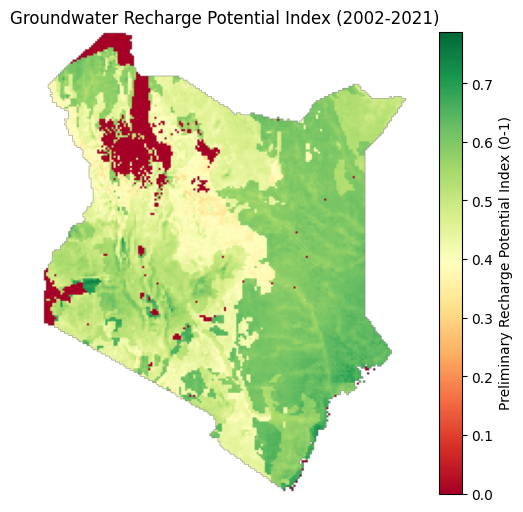

Index percentiles:
[0.         0.43971261 0.53009926 0.59705039 0.63575477]

Min: 0.0000, Max: 0.7883, Mean: 0.4940


In [47]:
#GROUNDWATER RECHARGE POTENTIAL
# Composite recharge potential index - Step 2: apply AHP weights to the
# normalized layers and sum into the final Weighted Linear Combination.

weights = {
    'rainfall_n':         0.2025,
    'hydrogeology_n':     0.2025,
    'slope_n':            0.2025,
    'pet_n':              0.0851,
    'lineament_density_n':0.0851,
    'ksat_n':             0.0498,
    'awc_n':              0.0498,
    'lulc_n':             0.0498,
    'drainage_density_n': 0.0498,
    'twi_n':              0.0230,
}

composite = ee.Image(0)
for band, w in weights.items():
    composite = composite.add(normalized.select(band).multiply(w))

composite = composite.rename('recharge_potential_index').updateMask(water_mask)

# Pull and visualize
comp_arr = np.squeeze(ee_to_numpy(composite, region=aoi, scale=5000))
aoi_mask = build_aoi_mask(comp_arr.shape)
comp_masked = np.where(aoi_mask, comp_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(comp_masked, cmap='RdYlGn')
plt.colorbar(label='Preliminary Recharge Potential Index (0-1)')
plt.title('Groundwater Recharge Potential Index (2002-2021)')
plt.axis('off')
plt.show()

print("Index percentiles:")
print(np.nanpercentile(comp_masked, [5, 25, 50, 75, 95]))
print(f"\nMin: {np.nanmin(comp_masked):.4f}, Max: {np.nanmax(comp_masked):.4f}, Mean: {np.nanmean(comp_masked):.4f}")

In [48]:
# Check which band(s) are actually masked/missing at the red-cluster locations,
# and whether that's distinguishable from a genuine near-zero composite value
mask_fraction = composite.mask().reduceRegion(
    reducer=ee.Reducer.mean(), geometry=aoi, scale=5000,
    maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()
print("Composite valid-pixel fraction across AOI:", mask_fraction)

# Per-band valid-pixel fraction, to isolate which input is causing gaps
for band in weights.keys():
    frac = normalized.select(band).mask().reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi, scale=5000,
        maxPixels=1e13, bestEffort=True, tileScale=4
    ).getInfo()
    print(f"  {band:<22s}: valid fraction = {frac[band]:.4f}")

Composite valid-pixel fraction across AOI: {'recharge_potential_index': 0.9370095152908002}
  rainfall_n            : valid fraction = 0.9772
  hydrogeology_n        : valid fraction = 0.9676
  slope_n               : valid fraction = 0.9776
  pet_n                 : valid fraction = 0.9466
  lineament_density_n   : valid fraction = 0.9776
  ksat_n                : valid fraction = 0.9781
  awc_n                 : valid fraction = 0.9773
  lulc_n                : valid fraction = 0.9774
  drainage_density_n    : valid fraction = 0.9772
  twi_n                 : valid fraction = 0.9772


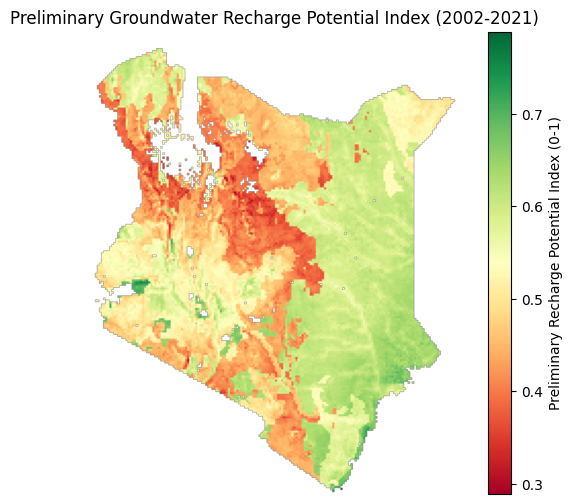

Index percentiles:
[0.38646937 0.45113728 0.54114869 0.59896248 0.63697075]

Min: 0.2889, Max: 0.7883, Mean: 0.5267
Fraction of AOI masked as invalid data: 0.0620


In [49]:
# Pull the composite's own validity mask alongside its value,
# so masked pixels are set to NaN instead of silently rendering as 0
comp_valid = np.squeeze(ee_to_numpy(composite.mask(), region=aoi, scale=5000))

aoi_mask = build_aoi_mask(comp_arr.shape)
valid_mask = aoi_mask & (comp_valid > 0)

comp_masked = np.where(valid_mask, comp_arr, np.nan)

plt.figure(figsize=(8, 6))
plt.imshow(comp_masked, cmap='RdYlGn')
plt.colorbar(label='Preliminary Recharge Potential Index (0-1)')
plt.title('Preliminary Groundwater Recharge Potential Index (2002-2021)')
plt.axis('off')
plt.show()

print("Index percentiles:")
print(np.nanpercentile(comp_masked, [5, 25, 50, 75, 95]))
print(f"\nMin: {np.nanmin(comp_masked):.4f}, Max: {np.nanmax(comp_masked):.4f}, Mean: {np.nanmean(comp_masked):.4f}")
print(f"Fraction of AOI masked as invalid data: {1 - np.nanmean(valid_mask[aoi_mask]):.4f}")

Jenks natural breaks: [np.float64(0.288864127910082), np.float64(0.4670880974490988), np.float64(0.5587731352947314), np.float64(0.7883298577174552)]


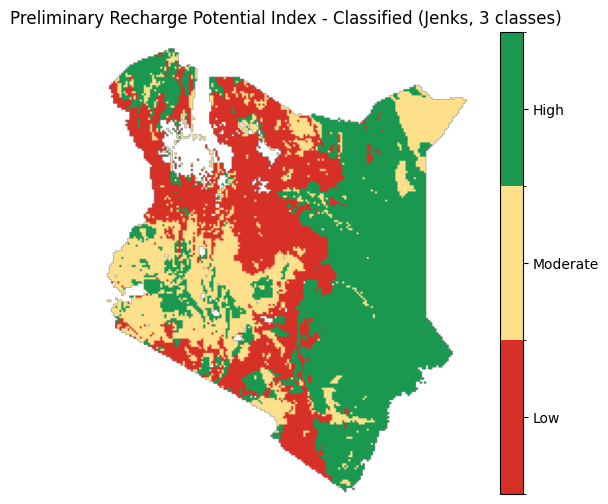


Class distribution:
  Low       : 6897 pixels (30.9%)
  Moderate  : 5097 pixels (22.9%)
  High      : 10300 pixels (46.2%)


In [51]:
# Classification - Jenks natural breaks (3 classes), replacing quantile classification
import jenkspy  # pip install jenkspy, if not already installed
from matplotlib.colors import ListedColormap, BoundaryNorm

valid_values = comp_masked[~np.isnan(comp_masked)]

breaks = jenkspy.jenks_breaks(valid_values, n_classes=3)
print("Jenks natural breaks:", breaks)

class_labels = ['Low', 'Moderate', 'High']
classified = np.full(comp_masked.shape, np.nan)
for i in range(3):
    lower, upper = breaks[i], breaks[i + 1]
    if i == 2:
        cls_mask = (comp_masked >= lower) & (comp_masked <= upper)
    else:
        cls_mask = (comp_masked >= lower) & (comp_masked < upper)
    classified[cls_mask] = i

cmap = ListedColormap(['#d73027', '#fee08b', '#1a9850'])  # red / yellow / green
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(8, 6))
im = plt.imshow(classified, cmap=cmap, norm=norm)
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(class_labels)
plt.title('Preliminary Recharge Potential Index - Classified (Jenks, 3 classes)')
plt.axis('off')
plt.show()

print("\nClass distribution:")
valid_total = np.sum(~np.isnan(classified))
for i, label in enumerate(class_labels):
    count = np.sum(classified == i)
    print(f"  {label:<10s}: {count} pixels ({count/valid_total*100:.1f}%)")

Correlation(rainfall_n, composite): 0.074
Correlation(hydrogeology_n, composite): 0.869
Correlation(slope_n, composite): 0.340


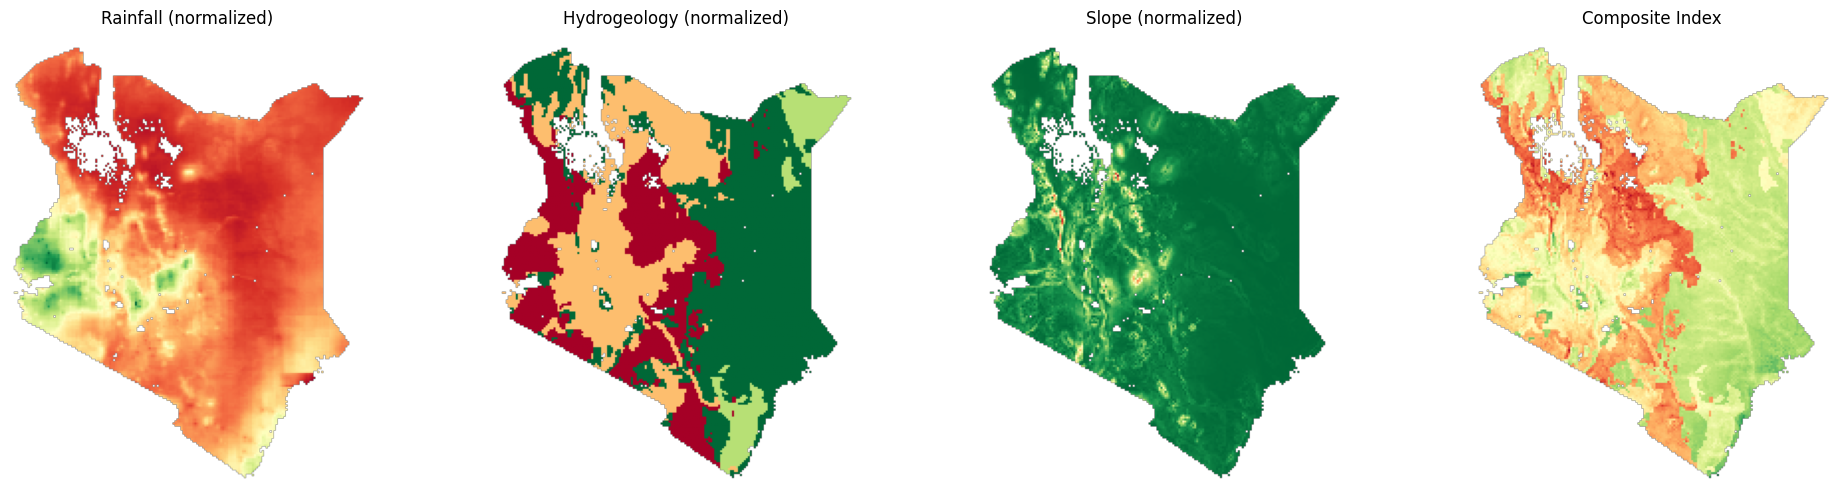

In [53]:
# Diagnostic: rainfall/hydrogeology/slope vs composite - pulled as ONE combined image
diagnostic_img = (composite
                   .addBands(composite.mask().rename('valid'))
                   .addBands(normalized.select('rainfall_n'))
                   .addBands(normalized.select('hydrogeology_n'))
                   .addBands(normalized.select('slope_n')))

diag_arr = ee_to_numpy(diagnostic_img, region=aoi, scale=5000)
diag_arr = np.squeeze(diag_arr)  # shape: (rows, cols, 5)

comp_arr2   = diag_arr[:, :, 0]
valid_arr2  = diag_arr[:, :, 1]
rain_n_arr  = diag_arr[:, :, 2]
hg_n_arr    = diag_arr[:, :, 3]
slope_n_arr = diag_arr[:, :, 4]

aoi_mask2 = build_aoi_mask(comp_arr2.shape)
valid2 = aoi_mask2 & (valid_arr2 > 0)

corr_rain  = np.corrcoef(rain_n_arr[valid2], comp_arr2[valid2])[0, 1]
corr_hg    = np.corrcoef(hg_n_arr[valid2], comp_arr2[valid2])[0, 1]
corr_slope = np.corrcoef(slope_n_arr[valid2], comp_arr2[valid2])[0, 1]
print(f"Correlation(rainfall_n, composite): {corr_rain:.3f}")
print(f"Correlation(hydrogeology_n, composite): {corr_hg:.3f}")
print(f"Correlation(slope_n, composite): {corr_slope:.3f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, arr, title in zip(
    axes,
    [np.where(valid2, rain_n_arr, np.nan), np.where(valid2, hg_n_arr, np.nan),
     np.where(valid2, slope_n_arr, np.nan), np.where(valid2, comp_arr2, np.nan)],
    ['Rainfall (normalized)', 'Hydrogeology (normalized)', 'Slope (normalized)', 'Composite Index']
):
    im = ax.imshow(arr, cmap='RdYlGn')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

Band order in diagnostic_img: ['recharge_potential_index', 'valid', 'rainfall_n', 'hydrogeology_n', 'slope_n']
Array shape: (226, 179, 5)
Correlation(rainfall_n, composite): 0.074
Correlation(hydrogeology_n, composite): 0.869
Correlation(slope_n, composite): 0.340


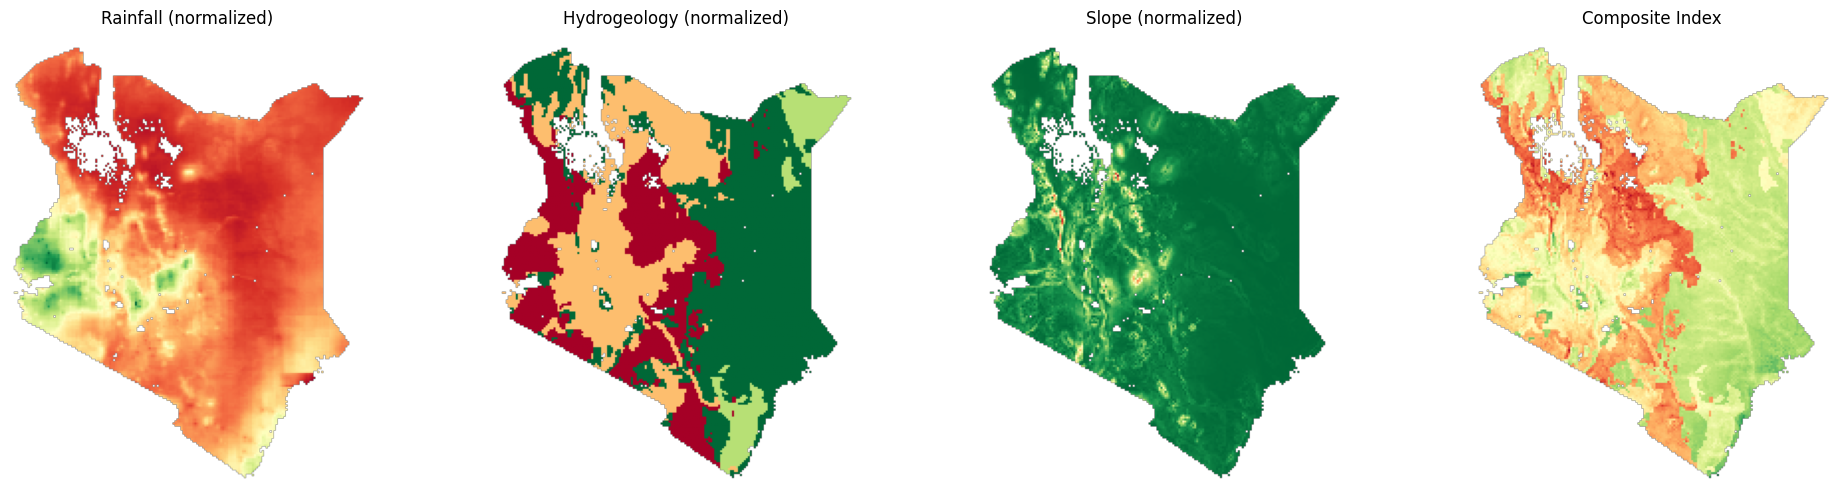

In [55]:
# Confirm actual band order before trusting any positional array slicing
print("Band order in diagnostic_img:", diagnostic_img.bandNames().getInfo())

diag_arr = ee_to_numpy(diagnostic_img, region=aoi, scale=5000)
diag_arr = np.squeeze(diag_arr)
print("Array shape:", diag_arr.shape)

band_order = diagnostic_img.bandNames().getInfo()
band_idx = {name: i for i, name in enumerate(band_order)}

comp_arr2   = diag_arr[:, :, band_idx['recharge_potential_index']]
valid_arr2  = diag_arr[:, :, band_idx['valid']]
rain_n_arr  = diag_arr[:, :, band_idx['rainfall_n']]
hg_n_arr    = diag_arr[:, :, band_idx['hydrogeology_n']]
slope_n_arr = diag_arr[:, :, band_idx['slope_n']]

aoi_mask2 = build_aoi_mask(comp_arr2.shape)
valid2 = aoi_mask2 & (valid_arr2 > 0)

corr_rain  = np.corrcoef(rain_n_arr[valid2], comp_arr2[valid2])[0, 1]
corr_hg    = np.corrcoef(hg_n_arr[valid2], comp_arr2[valid2])[0, 1]
corr_slope = np.corrcoef(slope_n_arr[valid2], comp_arr2[valid2])[0, 1]
print(f"Correlation(rainfall_n, composite): {corr_rain:.3f}")
print(f"Correlation(hydrogeology_n, composite): {corr_hg:.3f}")
print(f"Correlation(slope_n, composite): {corr_slope:.3f}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, arr, title in zip(
    axes,
    [np.where(valid2, rain_n_arr, np.nan), np.where(valid2, hg_n_arr, np.nan),
     np.where(valid2, slope_n_arr, np.nan), np.where(valid2, comp_arr2, np.nan)],
    ['Rainfall (normalized)', 'Hydrogeology (normalized)', 'Slope (normalized)', 'Composite Index']
):
    im = ax.imshow(arr, cmap='RdYlGn')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

Fresh rainfall min/max: {'rainfall_max': 2412.6310144364834, 'rainfall_min': 20.160484157528845}
Isolation image bands: ['rainfall_raw', 'rainfall_n_fresh']


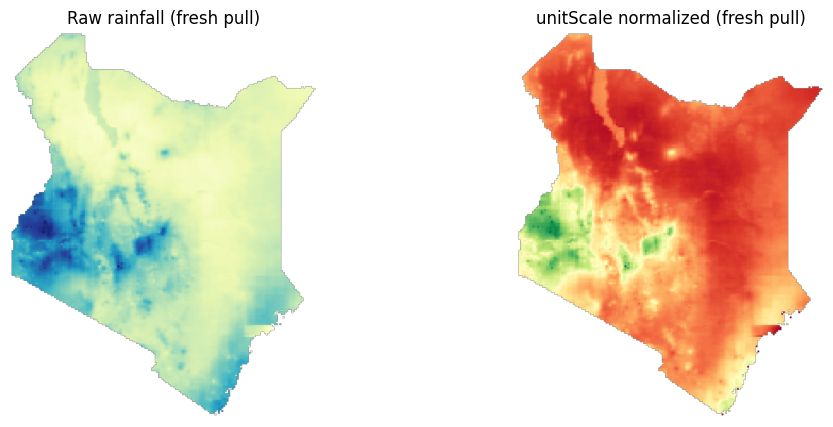


Sample check - high-rainfall region (west) vs low-rainfall region (north):
Raw max location value: 2412.6310144364834 -> normalized there: 1.0
Raw min location value: 0.0 -> normalized there: 0.0


In [56]:
# Isolate the normalization step in total isolation from the rest of the pipeline
rain_minmax_check = rain_mean.rename('rainfall').reduceRegion(
    reducer=ee.Reducer.minMax(), geometry=aoi, scale=5000,
    maxPixels=1e13, bestEffort=True, tileScale=4
).getInfo()
print("Fresh rainfall min/max:", rain_minmax_check)

norm_rainfall_fresh = rain_mean.rename('rainfall').unitScale(
    rain_minmax_check['rainfall_min'], rain_minmax_check['rainfall_max']
).rename('rainfall_n_fresh')

isolation_img = rain_mean.rename('rainfall_raw').addBands(norm_rainfall_fresh)
print("Isolation image bands:", isolation_img.bandNames().getInfo())

iso_arr = np.squeeze(ee_to_numpy(isolation_img, region=aoi, scale=5000))
raw_check = iso_arr[:, :, 0]
norm_check = iso_arr[:, :, 1]

aoi_mask4 = build_aoi_mask(raw_check.shape)
raw_masked = np.where(aoi_mask4, raw_check, np.nan)
norm_masked = np.where(aoi_mask4, norm_check, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw_masked, cmap='YlGnBu')
axes[0].set_title('Raw rainfall (fresh pull)')
axes[0].axis('off')
axes[1].imshow(norm_masked, cmap='RdYlGn')
axes[1].set_title('unitScale normalized (fresh pull)')
axes[1].axis('off')
plt.show()

# Direct point check: pick a known-wet pixel (west) and known-dry pixel (north)
# and print both raw and normalized values side by side
print("\nSample check - high-rainfall region (west) vs low-rainfall region (north):")
print("Raw max location value:", np.nanmax(raw_masked), "-> normalized there:",
      norm_masked.flatten()[np.nanargmax(raw_masked)])
print("Raw min location value:", np.nanmin(raw_masked), "-> normalized there:",
      norm_masked.flatten()[np.nanargmin(raw_masked)])